In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/Early-Sepsis-Detection"

Mounted at /content/drive
/content/drive/MyDrive/Early-Sepsis-Detection


In [10]:
!pip install xgboost lightgbm catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


# 11 — Baseline Model: Logistic Regression
### Early Sepsis Detection — Phase 13

The first trained model, using the leakage-safe, preprocessed arrays from
Phase 11 and `class_weight='balanced'` from Phase 12's analysis.

This is a BASELINE — later phases (14: more ML models, 15: tuning, 16:
deep learning) will be compared against these numbers, not the other way
around. No result here is claimed to be "good" or "bad" in isolation.


In [11]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

from src import config
from src import evaluate as ev

npz = np.load(config.PROCESSED_DIR / "model_ready_arrays.npz")
X_train, y_train = npz["X_train"], npz["y_train"]
X_val, y_val = npz["X_val"], npz["y_val"]
X_test, y_test = npz["X_test"], npz["y_test"]

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")


Train: (27560, 464) | Val: (5905, 464) | Test: (5906, 464)


## 1. Train the baseline model

`class_weight='balanced'` is used per Phase 12's analysis. `max_iter`
increased since scaled features with ~464 dimensions can need more
iterations to converge. The TEST SET is not touched until Section 4.


In [12]:
model = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=config.RANDOM_SEED)
model.fit(X_train, y_train)
print("Model trained.")


Model trained.


## 2. Evaluate on the VALIDATION set

The test set remains untouched here — validation is used for all
model-development decisions (this baseline check, later tuning in Phase
15, and threshold selection in Phase 18).


In [13]:
y_val_prob = model.predict_proba(X_val)[:, 1]
val_metrics = ev.compute_metrics(y_val, y_val_prob, threshold=0.5)
ev.print_metrics(val_metrics, model_name="Logistic Regression (val, threshold=0.5)")


--- Logistic Regression (val, threshold=0.5) (threshold=0.5) ---
  ROC-AUC:            0.7052
  PR-AUC:             0.1644
  Precision:          0.1309
  Recall (Sensitivity): 0.5854
  Specificity:        0.7410
  F1:                 0.2140
  Brier score:        0.1983
  Confusion matrix:   TN=4102 FP=1434 FN=153 TP=216


## 3. Diagnostic plots (validation set)

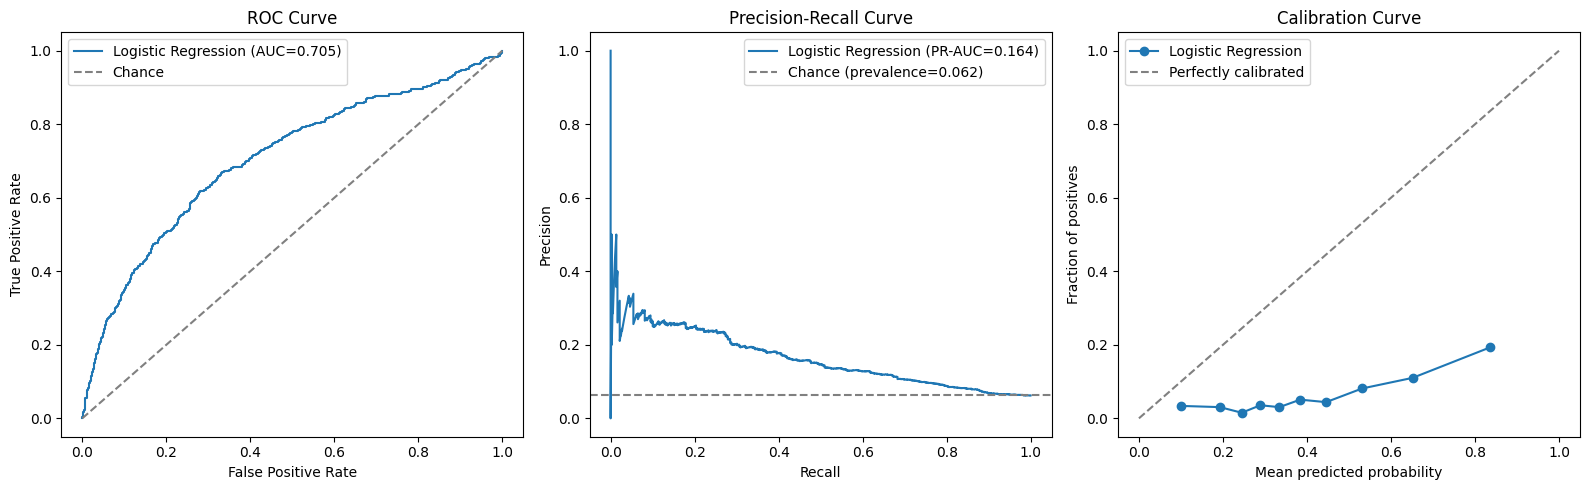

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ev.plot_roc_curve(y_val, y_val_prob, model_name="Logistic Regression", ax=axes[0])
ev.plot_pr_curve(y_val, y_val_prob, model_name="Logistic Regression", ax=axes[1])
ev.plot_calibration_curve(y_val, y_val_prob, model_name="Logistic Regression", ax=axes[2])
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "11_baseline_diagnostic_curves.png", dpi=150)
plt.show()


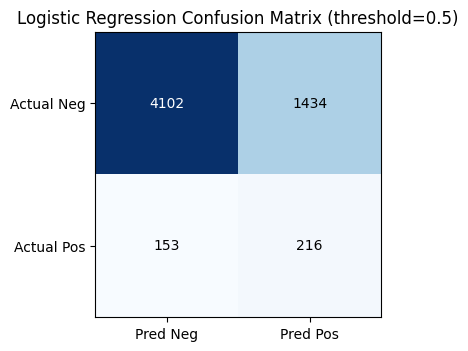

In [15]:
fig, ax = plt.subplots(figsize=(4, 4))
ev.plot_confusion_matrix(val_metrics, model_name="Logistic Regression", ax=ax)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "11_baseline_confusion_matrix.png", dpi=150)
plt.show()


## 4. Final check on the TEST set (using threshold=0.5 for now — Phase 18
will select a properly justified threshold using validation data only)


In [16]:
y_test_prob = model.predict_proba(X_test)[:, 1]
test_metrics = ev.compute_metrics(y_test, y_test_prob, threshold=0.5)
ev.print_metrics(test_metrics, model_name="Logistic Regression (TEST, threshold=0.5)")


--- Logistic Regression (TEST, threshold=0.5) (threshold=0.5) ---
  ROC-AUC:            0.7190
  PR-AUC:             0.1672
  Precision:          0.1337
  Recall (Sensitivity): 0.5919
  Specificity:        0.7437
  F1:                 0.2181
  Brier score:        0.1933
  Confusion matrix:   TN=4117 FP=1419 FN=151 TP=219


## 5. Save results for the Phase 17 model-comparison table

In [17]:
ev.save_model_results("Logistic_Regression_baseline_val", val_metrics)
ev.save_model_results("Logistic_Regression_baseline_test", test_metrics)

import joblib
joblib.dump(model, config.MODELS_DIR / "logistic_regression_baseline.pkl")
print("Saved model and results.")


2026-09-14 06:44:41,346 | INFO | src.evaluate | Saved/updated results for 'Logistic_Regression_baseline_val' in /content/drive/MyDrive/Early-Sepsis-Detection/reports/tables/model_comparison.csv
INFO:src.evaluate:Saved/updated results for 'Logistic_Regression_baseline_val' in /content/drive/MyDrive/Early-Sepsis-Detection/reports/tables/model_comparison.csv
2026-09-14 06:44:41,377 | INFO | src.evaluate | Saved/updated results for 'Logistic_Regression_baseline_test' in /content/drive/MyDrive/Early-Sepsis-Detection/reports/tables/model_comparison.csv
INFO:src.evaluate:Saved/updated results for 'Logistic_Regression_baseline_test' in /content/drive/MyDrive/Early-Sepsis-Detection/reports/tables/model_comparison.csv


Saved model and results.


## 6. Top coefficients (directional signal check, NOT causal interpretation)

**What?** The largest-magnitude logistic regression coefficients — which
features push the prediction most strongly toward/away from "sepsis".

**Caution:** these are associations within THIS model, not proof of
clinical causality, and can be affected by correlated features. Phase 20
(SHAP) will give a more robust, model-agnostic explanation.


In [18]:
feature_names = pd.read_csv(config.PROCESSED_DIR / "feature_names.csv")["feature_name"].tolist()
coef_df = pd.DataFrame({"feature": feature_names, "coefficient": model.coef_[0]})
coef_df["abs_coef"] = coef_df["coefficient"].abs()
top_coefs = coef_df.sort_values("abs_coef", ascending=False).head(20)
display(top_coefs[["feature", "coefficient"]])


,feature,coefficient
306,Potassium_last,2.036589
77,Resp_first,-1.964081
156,SaO2_mean,1.961874
305,Potassium_first,1.959894
78,Resp_last,1.837102
302,Potassium_min,-1.800526
303,Potassium_max,-1.725892
79,Resp_change,-1.695908
373,WBC_median,-1.603942
45,SBP_count,-1.447801


---
### What to send back to Claude after running this notebook

- Section 2's validation metrics (ROC-AUC, PR-AUC, recall, specificity especially)
- Section 4's test metrics
- Section 6's top-20 coefficients table

With that, **Phase 13 is complete**, and we move to **Phase 14 (Multiple
ML Models: Decision Tree, Random Forest, XGBoost, LightGBM, CatBoost)** —
all evaluated with this same `evaluate.py` module for a fair, consistent
comparison table.
